# 🖼️ Image Duplicate Detection Project

This notebook demonstrates a complete pipeline for detecting duplicate and near-duplicate images 
using multiple techniques:
- **MD5 hashing** for exact duplicates  
- **SimHash** for perceptual similarity  
- **MinHash (LSH)** for structural features  
- **FAISS** for deep feature similarity  

## ⚙️ Step 1: Imports

In [38]:
from pathlib import Path
from PIL import Image
import os
import cv2
import numpy as np
import torch
import faiss
from torchvision import transforms
from tqdm import tqdm
import timm
import hashlib
from simhash import Simhash
from colorama import Fore, Style, init
from datasketch import MinHash, MinHashLSH
from functools import lru_cache
import psutil, time
import itertools
from pathlib import Path
from collections import defaultdict
from typing import List, Set, Tuple, Dict, Any
import matplotlib.pyplot as plt

## 🧮 Step 2: Ground Truth and Evaluation Utilities

In [39]:
import sys
print(sys.executable)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe


In [40]:
def _build_ground_truth(all_files: List[Path]) -> List[List[Path]]:
    gt_groups_dict = defaultdict(list)
    
    for file_path in all_files:
        parts = file_path.name.split('_')
        if len(parts) >= 2:
            group_id = parts[0]  
            gt_groups_dict[group_id].append(file_path)
        else:
            gt_groups_dict[file_path.name].append(file_path)
            
    return list(gt_groups_dict.values())

def _get_pairs(groups: List[List[Path]]) -> Set[Tuple[Path, Path]]:
    all_pairs = set()
    for group in groups:
        for file1, file2 in itertools.combinations(group, 2):
            canonical_pair = tuple(sorted((file1, file2)))
            all_pairs.add(canonical_pair)
    return all_pairs

def calculate_metrics(predicted_groups: List[List[Path]], 
                      all_processed_files: List[Path]) -> Dict[str, Any]:
    gt_groups = _build_ground_truth(all_processed_files)
    gt_pairs = _get_pairs(gt_groups)
    tp_plus_fn = len(gt_pairs) 

    pred_pairs = _get_pairs(predicted_groups)
    tp_plus_fp = len(pred_pairs)

    tp_pairs = gt_pairs.intersection(pred_pairs)
    tp = len(tp_pairs)

    precision = tp / tp_plus_fp if tp_plus_fp > 0 else 0.0
    recall = tp / tp_plus_fn if tp_plus_fn > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

## 🧠 Step 3: Model and Image Preprocessing

In [41]:
# DEVICE setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_FOLDER = Path("DesSrc")

mem_hash = []
time_hash = []
metrics_hash = []

def get_model(model_name="resnet50"):
    model = timm.create_model(model_name, pretrained=True, num_classes = 0)
    model.to(DEVICE).eval() # move model to CPU/GPU, eval(): turn off dropout, batchnorm and use running stats
    return model

def get_transform():
    transform = transforms.Compose([
        # Normalize
        transforms.Resize((224,224)), # form of ResNet
        transforms.ToTensor(), # transform from PIL image (0-255) (H x W x C) ->torch.FloatTensor (0-1) (C x H x W)
        transforms.Normalize(mean = [0.485,0.456,0.406], std = [0.229,0.224,0.225]) # (x - mean) / std
    ])
    return transform

def read_image_cv2(file_path):
    img = cv2.imread(str(file_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(img)
    return img

## 🔑 Step 4: Stage 1 – Exact Duplicate Removal (MD5)
The MD5 hash identifies identical images bit-by-bit and removes perfect duplicates.

In [42]:
# MD5 - FILTER
def compute_md5(file_path):
    """Calculate MD5 hash for a image (bitwise)."""
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def remove_exact_duplicates(image_folder):
    image_paths = [f for f in image_folder.iterdir() if f.suffix.lower() in [".jpg", ".png", ".jpeg"]]
    hashes = {}
    duplicates = []

    image_files = list(Path(image_folder).glob("*.*"))
    total = len(image_files)

    for img_path in image_files:
        h = compute_md5(img_path)
        if h in hashes:
            duplicates.append(img_path)
        else:
            hashes[h] = img_path

    # delete duplicate
    for dup in duplicates:
        os.remove(dup)

    return list(hashes.values())

## 🧩 Step 5: Stage 2 – Perceptual Similarity using SimHash

SimHash generates a bit signature for each image based on local brightness features.
Pairs of images with Hamming distance below a threshold are considered duplicates.

In [43]:
def compute_simhash(file_path):
    try:
        img = cv2.imread(str(file_path))
        if img is None:
            return None
        img = cv2.resize(img, (64, 64))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        features = []
        for i in range(0, 64, 8):
            for j in range(0, 64, 8):
                block = gray[i:i+8, j:j+8]
                avg = int(block.mean())
                features.append(f"block_{i}_{j}_{avg//16}")
        return Simhash(features)
    except Exception as e:
        print(f"[Error] {file_path}: {e}")
        return None

def hamming_distance(hash1, hash2):
    return hash1.distance(hash2)

def simhash_group_duplicate(image_paths, threshold = 22):
    hashes = []
    for f in tqdm(image_paths, desc="Compute SimHash"):
        h = compute_simhash(f)
        if h:
            hashes.append((f,h))
    
    visited = set()
    groups = []
    representatives = []

    for i in range(len(hashes)):
        if i in visited:
            continue
        f1, h1 = hashes[i]
        group = [f1]
        visited.add(i)

        for j in range(i + 1, len(hashes)):
            if j in visited:
                continue
            f2, h2 = hashes[j]
            dist = hamming_distance(h1, h2)
            if(dist <= threshold):
                group.append(f2)
                visited.add(j)

        # Choose representative
        best_file = None
        best_score = -1
        for f in group:
            img = cv2.imread(str(f))
            if img is None:
                continue
            h, w, _ = img.shape
            score = h * w
            if score > best_score:
                best_score = score
                best_file = f

        groups.append(group)
        representatives.append(best_file)

    return groups, representatives

## 🧬 Step 6: Stage 3 – Structural Similarity using MinHash (Locality Sensitive Hashing)

MinHash converts image block-level features into hash signatures.
Images with similar feature sets are grouped using LSH.

In [44]:
def extract_features(image_path, size=(64,64), block_size=8, levels=16):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return set()
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    h, w = size
    features = []
    for bi in range(0, h, block_size):
        for bj in range(0, w, block_size):
            block = img[bi:bi+block_size, bj:bj+block_size]
            if block.size == 0:
                continue
            avg = int(block.mean())
            level = int(avg * (levels - 1) / 255)  # 0 .. levels-1
            features.append(f"b_{bi}_{bj}_{level}")
    return set(features)

# cache resolution checks
@lru_cache(maxsize=None)
def get_resolution(path):
    try:
        img = cv2.imread(str(path))
        if img is None:
            return 0
        h, w = img.shape[:2]
        return w * h
    except Exception:
        return 0

def minhash_group_duplicate(image_paths, threshold=0.9, num_perm=128,
                            block_size=8, levels=16, size=(64,64)):
    # Create LSH index
    lsh = MinHashLSH(threshold=threshold, num_perm=num_perm)
    minhashes = {}

    for path in tqdm(image_paths, desc="MinHashing"):
        features = extract_features(path, size=size, block_size=block_size, levels=levels)
        if not features:
            # skip images with no features
            continue
        m = MinHash(num_perm=num_perm)
        for f in features:
            m.update(f.encode('utf8'))
        minhashes[path] = m
        lsh.insert(str(path), m)

    # Cluster via BFS (connected components in LSH graph)
    groups, representatives = [], []
    visited = set()
    for path in list(minhashes.keys()):
        if path in visited:
            continue
        queue = [path]
        group = []
        while queue:
            current = queue.pop()
            if current in visited:
                continue
            visited.add(current)
            group.append(current)
            similar = lsh.query(minhashes[current])
            for s in similar:
                s_path = Path(s)
                if s_path not in visited and s_path in minhashes:
                    queue.append(s_path)

        # choose highest resolution representative
        rep = max(group, key=get_resolution)
        groups.append(group)
        representatives.append(rep)

    return groups, representatives

## ⚡ Step 7: Stage 4 – Deep Feature Similarity using FAISS

FAISS is used to perform approximate nearest neighbor search 
on deep embeddings extracted from pretrained CNN models.

In [45]:
def extract_embeddings_cv2(image_paths, batch_size = 32):
    # batch_size: number of image solving each time
    model = get_model()
    transforms = get_transform()
    embeddings = []
    valid_files = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc = "Extract embeddings"):
        batch_files = image_paths[i:i + batch_size]
        batch_imgs = []

        for f in batch_files:
            img = read_image_cv2(f)
            if img is None:
                continue
            img_tensor = transforms(img)
            batch_imgs.append(img_tensor)
            valid_files.append(f)

        #batch_imgs empty -> skip
        if not batch_imgs:
            continue

        batch_tensor = torch.stack(batch_imgs).to(DEVICE)
        with torch.no_grad():
            batch_emb = model(batch_tensor)
            batch_emb = batch_emb.cpu().numpy()
            embeddings.append(batch_emb)
    
    embeddings = np.vstack(embeddings)
    return embeddings, valid_files

def faiss_group_duplicate(embeddings, filenames, distance_threshold = 0.6, k_neighbors = 10):
    # - embeddings: numpy array (n, d)
    # - filenames: list Path
    # - distance_threshold: cosine similarity threshold
    # - k_neighbors: neighbors checking

    faiss.normalize_L2(embeddings)
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    D, neighbors = index.search(embeddings, k = k_neighbors)

    visited = set() 
    groups = []
    representatives = []

    for i, nbrs in enumerate(neighbors):
        if i in visited:
            continue
        group = [filenames[i]]
        visited.add(i)
        for j_idx, j in enumerate(nbrs[1:]): # skip itself
            if j in visited:
                continue
            sim = D[i, j_idx + 1]
            if sim >= distance_threshold:
                group.append(filenames[j])
                visited.add(j)
        # Choose representatives
        best_file = None
        best_score = -1
        for f in group:
            img = read_image_cv2(f)
            if img is None:
                continue
            w, h = img.size
            score = w * h
            if score > best_score:
                best_score = score
                best_file = f
        groups.append(group)
        representatives.append(best_file)
    return groups, representatives

## 📊 Step 8: Reporting, Logging, and Evaluation Metrics

Utility functions for summarizing results, timing, memory usage, and computing precision/recall/F1 metrics.

In [46]:
# Config output
init(autoreset=True)

def print_summary(groups, representatives, all_processed_files, image_folder, metrics=None, total_initial=None, after_md5=None, 
                  elapsed_time=None, mem_used=None):
    print("\n" + "="*70)
    print(Fore.CYAN + Style.BRIGHT + "📊 DUPLICATE DETECTION SUMMARY".center(70))
    print("="*70)

    if total_initial is not None:
        print(f"{Fore.YELLOW}Total Initial Images: {Fore.WHITE}{total_initial}")
    if after_md5 is not None:
        removed = total_initial - after_md5 if total_initial is not None else "?"
        print(f"{Fore.YELLOW}Remaining After MD5 Filter: {Fore.WHITE}{after_md5} "
              f"({removed} removed)")

    print(f"{Fore.YELLOW}Total Clusters Found: {Fore.WHITE}{len(groups)}")
    print(f"{Fore.YELLOW}Total Representatives: {Fore.WHITE}{len(representatives)}")
    print(f"{Fore.YELLOW}Total Processed Images: {Fore.WHITE}{len(all_processed_files)}")
    print(f"{Fore.YELLOW}Cleaned Folder: {Fore.WHITE}{Path(image_folder) / 'cleaned'}")

    print("\n" + "="*70)
    print(Fore.CYAN + Style.BRIGHT + "📊 PERFORMANCE EVALUATION".center(70))
    print("="*70)

    if elapsed_time is not None:
        print(f"{Fore.GREEN}Processing Time: {Fore.WHITE}{elapsed_time:.2f} seconds")
    if mem_used is not None:
        print(f"{Fore.GREEN}Memory Used: {Fore.WHITE}{mem_used:.2f} MB")

    print("\n" + "="*70)
    print(Fore.CYAN + Style.BRIGHT + "📊 SOME CLUSTERS".center(70))
    print("="*70)
    for idx, group in enumerate(groups):
        if idx >= 5:
            break
        rep = representatives[idx]
        rep_name = rep.name if hasattr(rep, "name") else Path(rep).name
        print(f"{Fore.CYAN}Cluster {idx + 1:>3} {Fore.WHITE}| {len(group):>3} images | "
              f"Representative: {Fore.GREEN}{rep_name}")
    print("-"*70)

    if metrics:
        print("\n" + "="*70)
        print(Fore.CYAN + Style.BRIGHT + "📊 EVALUATION METRICS".center(70))
        print("="*70)
        print(f"{Fore.CYAN}Precision: {Fore.WHITE}{metrics.get('precision', 0)*100:.2f}%")
        print(f"{Fore.CYAN}Recall:    {Fore.WHITE}{metrics.get('recall', 0)*100:.2f}%")
        print(f"{Fore.CYAN}F1-Score:  {Fore.WHITE}{metrics.get('f1_score', 0)*100:.2f}%")
    print("="*70 + "\n")


def get_memory_usage():
    process = psutil.Process(os.getpid())
    mem_bytes = process.memory_info().rss
    return mem_bytes / (1024 ** 2)

## 🚀 Step 9: Main Pipeline

The `main()` function orchestrates the entire process:
1. Remove exact duplicates  
2. Apply chosen method (`faiss`, `simhash`, `minhash`)  
3. Measure time & memory  
4. Compute evaluation metrics  
5. Save representative images

In [47]:
def main(image_folder, method = "faiss", model_name="resnet50"):

    image_paths = [f for f in image_folder.iterdir() if f.suffix.lower() in [".jpg", ".png", ".jpeg"]]
    total_initial = len(image_paths)

    unique_images = remove_exact_duplicates(image_folder)
    after_md5 = len(unique_images)

    #print(f"After remove absolute duplicates, remaining {len(unique_images)} valid images.\n")

    groups = []
    representatives = []
    all_processed_files= [] 

    # Timing
    start_time = time.time()
    mem_before = get_memory_usage()

    if method == "faiss":
        embeddings, valid_files = extract_embeddings_cv2(unique_images, batch_size=32)
        groups, representatives = faiss_group_duplicate(embeddings, valid_files, distance_threshold=0.6, k_neighbors=10)
        all_processed_files = valid_files

    elif method == "simhash":
        # Binary signature
        groups, representatives = simhash_group_duplicate(unique_images, threshold=16) 
        all_processed_files = unique_images
    
    elif method == "minhash":
        # MinHash + LSH
        groups, representatives = minhash_group_duplicate(unique_images, threshold=0.6)
        all_processed_files = unique_images

    else:
        raise ValueError(f"Unknown method: {method}. Choose from ['faiss', 'simhash', 'minhash'].")
    
    # Result of timing

    elapsed_time = time.time() - start_time
    mem_after = get_memory_usage()
    mem_used = mem_after - mem_before

    output_folder = image_folder / ("Cleaned" + method)
    output_folder.mkdir(exist_ok=True)
    for f in representatives:
        img = cv2.imread(str(f))
        cv2.imwrite(str(output_folder / f.name), img)

    print(f"\nCleaned folder: {output_folder}")

    # Evaluation
    metrics = None
    if all_processed_files:
        metrics = calculate_metrics(groups, all_processed_files)
    else:
        print(Fore.RED + "\n⚠️ Cannot evaluate because no images were processed.")

    mem_hash.append(mem_used)
    time_hash.append(elapsed_time)
    metrics_hash.append(metrics)

    print_summary(groups, representatives, all_processed_files, image_folder, metrics, total_initial=total_initial, after_md5=after_md5,
                  elapsed_time=elapsed_time, mem_used=mem_used)
    return groups, representatives


## 🧪 Step 10: Run the Experiments

Run the pipeline using all three methods to compare their performance 
and clustering quality.

In [48]:
methods = ["faiss", "simhash", "minhash"]
models = ["resnet50", "efficientnet_b0", "mobilenetv3_large_100", "vit_base_patch16_224"]
groups, representatives = main(IMAGE_FOLDER, method=methods[0], model_name=models[0])
main(IMAGE_FOLDER, method=methods[1], model_name=models[0])
main(IMAGE_FOLDER, method=methods[2], model_name=models[0])

Extract embeddings: 100%|██████████| 31/31 [01:09<00:00,  2.25s/it]



Cleaned folder: DesSrc\Cleanedfaiss

                    📊 DUPLICATE DETECTION SUMMARY                     
Total Initial Images: 990
Remaining After MD5 Filter: 990 (0 removed)
Total Clusters Found: 100
Total Representatives: 100
Total Processed Images: 990
Cleaned Folder: DesSrc\cleaned

                       📊 PERFORMANCE EVALUATION                       
Processing Time: 80.74 seconds
Memory Used: 43.32 MB

                           📊 SOME CLUSTERS                            
Cluster   1 |  10 images | Representative: fl80_5.jpg
Cluster   2 |   2 images | Representative: fl16_4.jpg
Cluster   3 |  10 images | Representative: fl11_0.jpg
Cluster   4 |  10 images | Representative: fl12_0.jpg
Cluster   5 |  10 images | Representative: fl13_0.jpg
----------------------------------------------------------------------

                         📊 EVALUATION METRICS                         
Precision: 99.77%
Recall:    99.39%
F1-Score:  99.58%



Compute SimHash: 100%|██████████| 990/990 [00:07<00:00, 139.92it/s]



Cleaned folder: DesSrc\Cleanedsimhash

                    📊 DUPLICATE DETECTION SUMMARY                     
Total Initial Images: 990
Remaining After MD5 Filter: 990 (0 removed)
Total Clusters Found: 689
Total Representatives: 689
Total Processed Images: 990
Cleaned Folder: DesSrc\cleaned

                       📊 PERFORMANCE EVALUATION                       
Processing Time: 14.69 seconds
Memory Used: 0.00 MB

                           📊 SOME CLUSTERS                            
Cluster   1 |   8 images | Representative: fl68_3.jpg
Cluster   2 |   4 images | Representative: fl68_0.jpg
Cluster   3 |   1 images | Representative: fl10_4.jpg
Cluster   4 |   1 images | Representative: fl10_5.jpg
Cluster   5 |   1 images | Representative: fl10_8.jpg
----------------------------------------------------------------------

                         📊 EVALUATION METRICS                         
Precision: 62.22%
Recall:    7.54%
F1-Score:  13.45%



MinHashing: 100%|██████████| 990/990 [00:07<00:00, 132.79it/s]



Cleaned folder: DesSrc\Cleanedminhash

                    📊 DUPLICATE DETECTION SUMMARY                     
Total Initial Images: 990
Remaining After MD5 Filter: 990 (0 removed)
Total Clusters Found: 823
Total Representatives: 823
Total Processed Images: 990
Cleaned Folder: DesSrc\cleaned

                       📊 PERFORMANCE EVALUATION                       
Processing Time: 18.09 seconds
Memory Used: 7.18 MB

                           📊 SOME CLUSTERS                            
Cluster   1 |   6 images | Representative: fl10_0.jpg
Cluster   2 |   1 images | Representative: fl10_1.jpg
Cluster   3 |   1 images | Representative: fl10_4.jpg
Cluster   4 |  11 images | Representative: fl10_6.jpg
Cluster   5 |   1 images | Representative: fl10_9.jpg
----------------------------------------------------------------------

                         📊 EVALUATION METRICS                         
Precision: 73.74%
Recall:    8.19%
F1-Score:  14.75%



([[WindowsPath('DesSrc/fl10_0.jpg'),
   WindowsPath('DesSrc/fl10_8.jpg'),
   WindowsPath('DesSrc/fl10_3.jpg'),
   WindowsPath('DesSrc/fl10_7.jpg'),
   WindowsPath('DesSrc/fl10_5.jpg'),
   WindowsPath('DesSrc/fl10_2.jpg')],
  [WindowsPath('DesSrc/fl10_1.jpg')],
  [WindowsPath('DesSrc/fl10_4.jpg')],
  [WindowsPath('DesSrc/fl10_6.jpg'),
   WindowsPath('DesSrc/fl61_5.jpg'),
   WindowsPath('DesSrc/fl61_3.jpg'),
   WindowsPath('DesSrc/fl61_1.jpg'),
   WindowsPath('DesSrc/fl61_2.jpg'),
   WindowsPath('DesSrc/fl61_9.jpg'),
   WindowsPath('DesSrc/fl61_7.jpg'),
   WindowsPath('DesSrc/fl61_6.jpg'),
   WindowsPath('DesSrc/fl61_8.jpg'),
   WindowsPath('DesSrc/fl61_4.jpg'),
   WindowsPath('DesSrc/fl61_0.jpg')],
  [WindowsPath('DesSrc/fl10_9.jpg')],
  [WindowsPath('DesSrc/fl11_0.jpg')],
  [WindowsPath('DesSrc/fl11_1.jpg')],
  [WindowsPath('DesSrc/fl11_2.jpg')],
  [WindowsPath('DesSrc/fl11_3.jpg')],
  [WindowsPath('DesSrc/fl11_4.jpg')],
  [WindowsPath('DesSrc/fl11_5.jpg')],
  [WindowsPath('DesSrc/fl11

## 🖼️ Step 11: Visualization of Image Groups

Display representatives and group thumbnails in an interactive OpenCV window.  
Press:
- `n` → next images  
- `p` → previous images  
- `q` → quit visualization

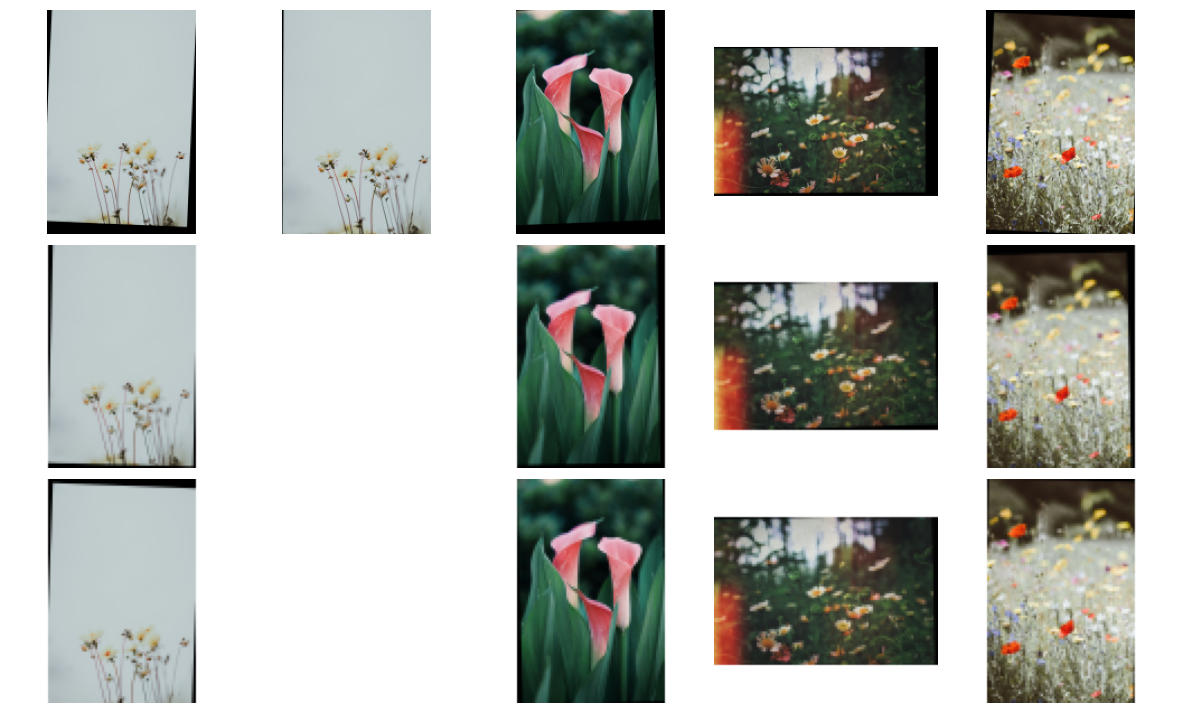

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ---------------- Helper Functions ----------------

def resize_and_pad(image, target_w, target_h, bg_color=(255,255,255)):
    if image is None:
        return np.full((target_h, target_w, 3), bg_color, dtype=np.uint8)
    h, w = image.shape[:2]
    if h == 0 or w == 0:
        return np.full((target_h, target_w, 3), bg_color, dtype=np.uint8)
    ratio = min(target_w / w, target_h / h)
    new_w = max(1, int(w * ratio))
    new_h = max(1, int(h * ratio))
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    padded = np.full((target_h, target_w, 3), bg_color, dtype=np.uint8)
    x_offset = (target_w - new_w)//2
    y_offset = (target_h - new_h)//2
    padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return padded

def safe_imread(path):
    try:
        return cv2.imread(str(path))
    except Exception:
        return None

def to_rgb(img):
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---------------- Config ----------------
n_groups = 5  # số group hiển thị tối đa
REP_H = 200
REP_W = 200
THUMB_H = 100
THUMB_W = 100
PADDING = 10

# ---------------- Layout ----------------
display_indices = list(range(min(n_groups, len(groups))))
n_display = len(display_indices)
if n_display == 0:
    raise ValueError("Không có group nào để hiển thị.")

rows = 3  # representative + 2 rows thumbnails
cols = n_display

# ---------------- Current indices thumbnails ----------------
current_indices = [1]*n_display  # start index cho thumbnails

# ---------------- Matplotlib interactive ----------------
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.array([axes])
elif cols == 1:
    axes = axes[:, np.newaxis]

plt.subplots_adjust(wspace=0.05, hspace=0.05)

def update_display():
    for display_pos, idx in enumerate(display_indices):
        group = groups[idx]

        # Representative
        rep_path = group[0]
        rep_img = to_rgb(resize_and_pad(safe_imread(rep_path), REP_W, REP_H))
        axes[0, display_pos].imshow(rep_img)
        axes[0, display_pos].axis('off')

        # Thumbnails 2x2
        start_idx = current_indices[display_pos]
        for j in range(4):
            img_idx = start_idx + j
            row = 1 + j//2
            col = display_pos
            axes[row, col].cla()  # clear old image
            if img_idx < len(group):
                thumb_img = to_rgb(resize_and_pad(safe_imread(group[img_idx]), THUMB_W, THUMB_H))
                axes[row, col].imshow(thumb_img)
            axes[row, col].axis('off')
    fig.canvas.draw_idle()

def on_key(event):
    if event.key == 'q':
        plt.close(fig)
    elif event.key == 'n':
        for k in range(n_display):
            new_index = current_indices[k] + 4
            if new_index >= len(groups[display_indices[k]]):
                new_index = 1
            current_indices[k] = new_index
        update_display()
    elif event.key == 'p':
        for k in range(n_display):
            new_index = current_indices[k] - 4
            if new_index < 1:
                new_index = 1
            current_indices[k] = new_index
        update_display()

fig.canvas.mpl_connect('key_press_event', on_key)
update_display()
plt.show()


## 📈 Step 12: Performance Comparison Charts

Visualize memory usage, runtime, and metric scores (precision, recall, F1) across methods.

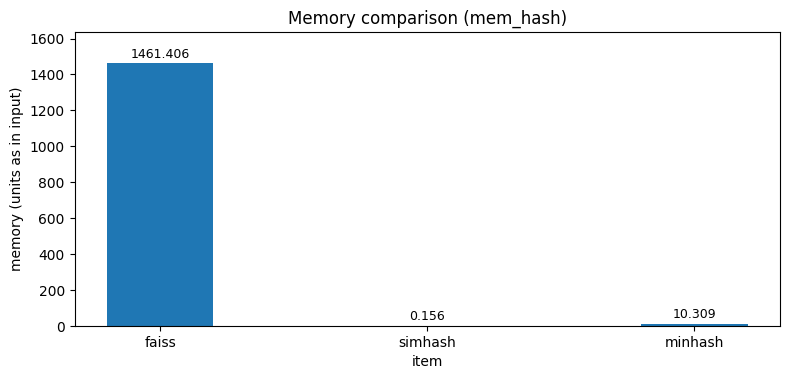

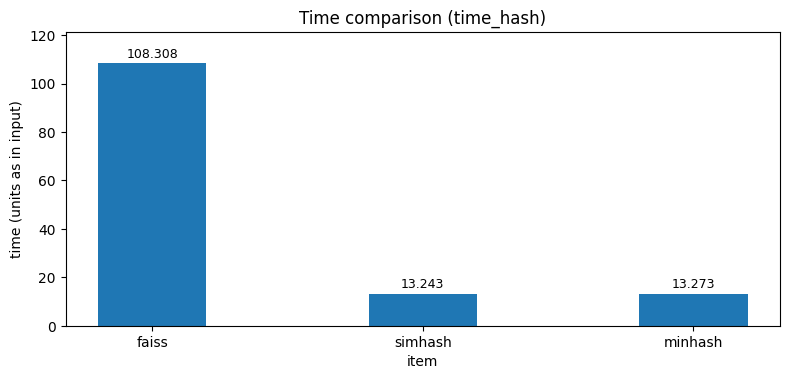

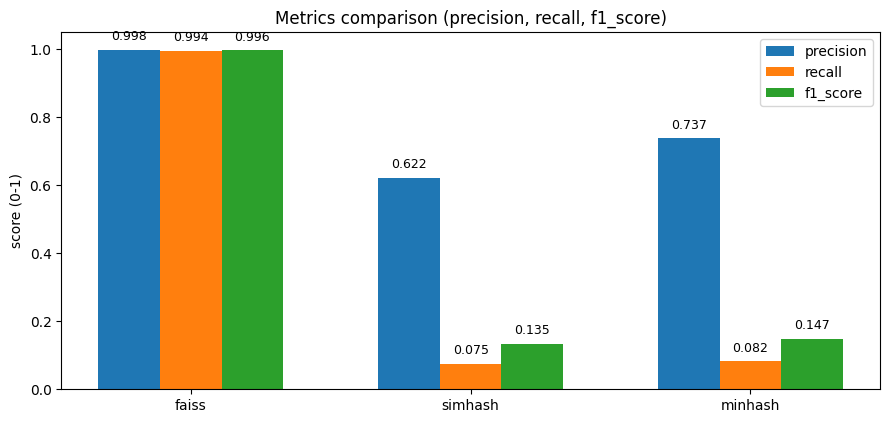

In [37]:

def annotate_bars(ax, bars, fmt="{:.3f}", offset_ratio=0.01):
    """Ghi giá trị lên đầu mỗi cột; clip_on=False để text không bị cắt."""
    ylim = ax.get_ylim()
    height_range = ylim[1] - ylim[0] if ylim[1] != ylim[0] else 1.0
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + height_range * offset_ratio,
            fmt.format(h),
            ha='center',
            va='bottom',
            fontsize=9,
            clip_on=False
        )

def plot_memory(methods, mem_hash, save=False, fname=None):
    fig, ax = plt.subplots(figsize=(8,4))
    x = np.arange(len(methods))
    width = 0.40
    bars = ax.bar(x, mem_hash, width=width)
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_title('Memory comparison (mem_hash)')
    ax.set_xlabel('item')
    ax.set_ylabel('memory (units as in input)')

    y_max = max(mem_hash) if mem_hash else 1.0
    ax.set_ylim(0, y_max + y_max * 0.12)
    annotate_bars(ax, bars, "{:.3f}", offset_ratio=0.01)

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    if save and fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    else:
        plt.show()

def plot_time(methods, time_hash, save=False, fname=None, use_symlog=False):
    fig, ax = plt.subplots(figsize=(8,4))
    x = np.arange(len(methods))
    width = 0.40
    bars = ax.bar(x, time_hash, width=width)
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_title('Time comparison (time_hash)')
    ax.set_xlabel('item')
    ax.set_ylabel('time (units as in input)')

    if use_symlog:
        ax.set_yscale('symlog', linthresh=1.0)
    else:
        y_max = max(time_hash) if time_hash else 1.0
        ax.set_ylim(0, y_max + y_max * 0.12)

    annotate_bars(ax, bars, "{:.3f}", offset_ratio=0.01)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    if save and fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    else:
        plt.show()

def plot_metrics(methods, metrics_hash, save=False, fname=None):
    precision = [d.get('precision', 0.0) for d in metrics_hash]
    recall = [d.get('recall', 0.0) for d in metrics_hash]
    f1 = [d.get('f1_score', 0.0) for d in metrics_hash]

    x = np.arange(len(methods))
    width = 0.22

    fig, ax = plt.subplots(figsize=(9,4.5))
    bars_p = ax.bar(x - width, precision, width)
    bars_r = ax.bar(x, recall, width)
    bars_f = ax.bar(x + width, f1, width)

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_title('Metrics comparison (precision, recall, f1_score)')
    ax.set_ylabel('score (0-1)')
    ax.set_ylim(0, 1.05)

    annotate_bars(ax, bars_p, "{:.3f}", offset_ratio=0.02)
    annotate_bars(ax, bars_r, "{:.3f}", offset_ratio=0.02)
    annotate_bars(ax, bars_f, "{:.3f}", offset_ratio=0.02)

    ax.legend(['precision', 'recall', 'f1_score'])
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    if save and fname:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    else:
        plt.show()

plot_memory(methods, mem_hash, save=False, fname='mem_hash.png')
plot_time(methods, time_hash, save=False, fname='time_hash.png', use_symlog=False)
plot_metrics(methods, metrics_hash, save=False, fname='metrics_hash.png')

# 🏁 Conclusion

- **FAISS** performs best on semantic duplicates (content-based).  
- **SimHash** is fast but less accurate for small changes.  
- **MinHash** balances speed and robustness. 